In [33]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop , Adagrad , SGD

In [34]:
data = pd.read_csv(r"C:\Users\KOIN\Downloads\titanic (1).csv")

# Preprocessing
data = data.drop(['Name', 'Ticket', 'Cabin'], axis=1)
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)

# Features and target
x = data.drop('Survived', axis=1)
y = data['Survived']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

C:\Users\KOIN\AppData\Local\Temp\ipykernel_22188\967043250.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
C:\Users\KOIN\AppData\Local\Temp\ipykernel_22188\967043250.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [43]:
def create_model():
    model = Sequential()
    model.add(Dense(32, input_dim=x_train.shape[1], activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [44]:
rmsprop_model = create_model()
rmsprop_opt = RMSprop(learning_rate=0.01)

rmsprop_model.compile( optimizer= rmsprop_opt , loss = "binary_crossentropy" , metrics=["accuracy"])

rmsprop_his = rmsprop_model.fit(x_train , y_train , validation_data=(x_train , y_train) , epochs=100 , batch_size=32 , verbose=0 )

In [45]:
adagard_model = create_model()
adagard_opt = Adagrad(learning_rate=0.01)

adagard_model.compile( optimizer= adagard_opt , loss = "binary_crossentropy" , metrics=["accuracy"])

adagard_his = adagard_model.fit(x_train , y_train , validation_data=(x_train , y_train) , epochs=100 , batch_size=32 , verbose=0 )

In [38]:
nag_model = create_model()

nag_opt = SGD(learning_rate=0.01)

nag_model.compile(optimizer= nag_opt , loss= "binary_crossentropy" , metrics=["accuracy"])

nag_his = nag_model.fit(x_train , y_train  , validation_data=(x_train , y_train ) , epochs= 100 , batch_size=32 , verbose=0)

In [39]:
moment_model = create_model()

moment_opt = SGD(learning_rate=0.01)

moment_model.compile(optimizer= moment_opt ,  loss= "binary_crossentropy" , metrics =["accuracy"])

moment_his = moment_model.fit(x_train , y_train , validation_data=(x_train , y_train ) , epochs=100 , batch_size= 32 , verbose= 0 )

In [40]:
import matplotlib.pyplot as plt

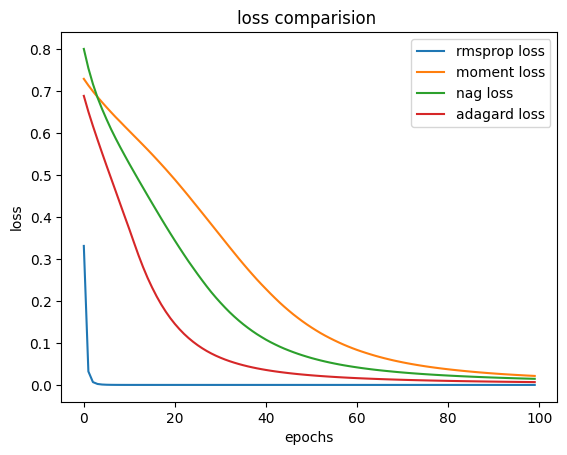

In [41]:
plt.plot(rmsprop_his.history["loss"] , label=["rmsprop loss"])
plt.plot(moment_his.history["loss"] , label=["moment loss"])
plt.plot(nag_his.history["loss"] , label=["nag loss"])
plt.plot(adagard_his.history["loss"] , label="adagard loss")

plt.title("loss comparision ")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

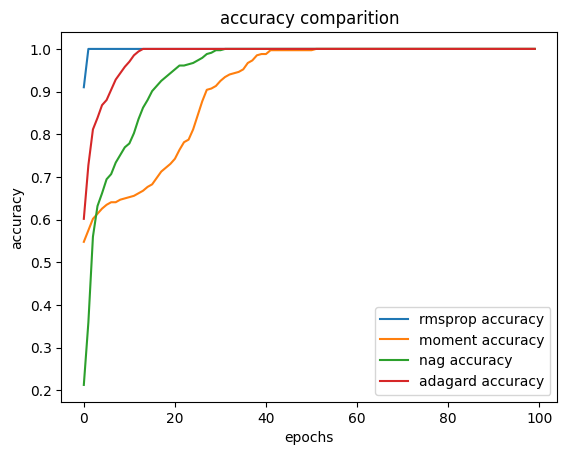

In [42]:
plt.plot(rmsprop_his.history["accuracy"] , label=["rmsprop accuracy"])
plt.plot(moment_his.history["accuracy"] , label=["moment accuracy"])
plt.plot(nag_his.history["accuracy"] , label=["nag accuracy"])
plt.plot(adagard_his.history["accuracy"] , label=["adagard accuracy"])

plt.title("accuracy comparition")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()